
<font size = "5"> **IMC21 Workshop:\n [AI Methods for Microscopy Analysis and Knowledge Extraction](../ICM21_AImic2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />

[Download](https://github.com//pycroscopy/MLSTEM2026/raw/refs/heads/main/notebooks/2%20pm%20Autonomous_Microscopy_Digital_Twin.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github//pycroscopy/IMC21-Workshop/blob/main/notebooks/2%20pm%20Autonomous_Microscopy_Digital_Twin.ipynb)
   
# pycroscopy, sidpy and SciFiReaders 
part of the ICM21 workshop of

<font size = "5"> **[Artificial Intelligence Methods for Microscopy Analysis and Knowledge Extraction](../ICM21_AImic2026.ipynb)**</font>

---
Gerd Duscher - University of Tennessee, Knoxville


<div style="max-width: 80%; border-left: 6px solid #2e7d32; border-top: 1px solid #e0e0e0; border-right: 1px solid #e0e0e0; border-bottom: 1px solid #e0e0e0; border-radius: 4px; padding: 0; margin-bottom: 20px; box-shadow: 0 4px 8px rgba(0,0,0,0.1), 0 1px 3px rgba(0,0,0,0.08); background-color: #ffffff;">
  <div style="background-color: transparent; color: #1b5e20; padding: 10px 15px; font-weight: bold; border-bottom: 1px solid #e0e0e0; display: flex; align-items: center; gap: 8px;">
    <span>🎯</span> Learning Goals
  </div>
  <div style="padding: 15px; background-color: transparent; color: #333333;">
  <ul style="margin: 0; padding-left: 20px;">
      <li style="margin-bottom: 8px;">Getting familiar with the pycroscopy ecosystem.</li>
      <li style="margin-bottom: 8px;">Visualizing data stored in various formats.</li>
      <li style="margin-bottom: 0;">Utilizing the generic sidpy data format as a base for conventional and machine learning based data analysis.</li>
    </ul>
  </div>
</div>


***

## Data Representation 

All notebooks of this notebook series rely on two core python-packages: [numpy](https://numpy.org/) and [matplotlib](https://matplotlib.org/)

However,  ``numpy`` and ``matplot`` are a bit confusing of how they are dealing with images from microscopes.

The reason for these problems is that matplotlib is an image **and** a line plotting routine, and those routines are using different conventions of the plotting axis.

The behaviour of these two packages will be explored in this notebook, and the differences of between [numpy](https://numpy.org/) and [matplotlib](https://matplotlib.org/) have direct impact on how we deal with data, how we store them, and how easily we can use other packages for data analysis.

***

There is only one command necessary to load the functionality of both packages (numpy and matplotlib) which is done in the code cell below. Every notebook in this series will start with that line.

In [1]:
%matplotlib ipympl
import sys
import os

import gdown
if 'google.colab' in sys.modules:
    !pip install  ipympl -q
    from google.colab import output
    output.enable_custom_widget_manager()
%load_ext autoreload
%autoreload 2

sys.path.insert(0,'../../pyTEMlib/')
import matplotlib.pylab as plt
import numpy as np
import pyTEMlib

### The Problem

An image is stored as a matrix where each element of the matrix is the intensity level of the pixel.

An empty image can easily be made with numpy (``np.zeros`` function)

In [3]:
image = np.zeros((8,4))

#make checkerboard (you can ignore how this is done exactly, the result is important)
image[::2, 1::2] = 1
image[1::2, ::2] = 1
print(image)

[[0. 1. 0. 1.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 0. 1. 0.]]


Looks ok.

Let's plot this boring image.

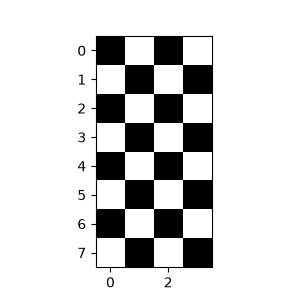

In [4]:
plt.figure(figsize = (3,3))
plt.imshow(image, cmap = plt.cm.gray)
plt.show()

While you probably did not have a problem with the matrix representation of our boring image, you should have one now, because the x-axis was the longer one.

The problem comes from the different way data can be stored.

## Data Storage Conventions

In microscopy, we are used to first go right and then down, like you read a text in English. This may originate in the fact that images from scanning microscopes start at top left, go horizontally first and then down line by line.

So our perception requires the first index to be horizontally (the column index to be first) and the row index to be the second.

In mathematics, a matrix index starts with a row index and column indices are second. Exactly opposite to what we are used in microscopy.



\begin{bmatrix}
    x_{11} & x_{12} & x_{13} & \dots  & x_{1n} \\
    x_{21} & x_{22} & x_{23} & \dots  & x_{2n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    x_{d1} & x_{d2} & x_{d3} & \dots  & x_{dn}
\end{bmatrix}


So we now have to choose, what kind of internal representation we use. And we need to consider what kind of internal representation the used python-packages choose. You will notice that most examples on the internet get around this problem by using square matrices and images, which leads sometimes to errors in non-square data, and leads often to subtle problems in image analysis.

As we see numpy uses the mathematical convention and most popular packages are compatible with numpy and use the same convention. If we chose to internally stay with the fast direction as row in the numpy array, it gets confusing with switching x and y directions constantly. Therefore, ``pyTEMlib``, ``pycroscopy``, and ``pyNSID`` are using the storage method of slow axis first storage convention.

In other words, in the notebooks of this course, we will rotate output and stay with mathematics indexing internally. This makes the computation consistent with all numpy based packages and there are many. The [scipy](https://www.scipy.org/), [scikit-image](https://scikit-image.org/), and [scikit-learn](https://scikit-learn.org/stable/) are the most used (collection of) packages used in this notebook-lecture series. We stay  very ``pythonic`` with this convention.

*Turning* the image can be accomplished by a ``.T`` command of numpy arrays, which is the transposed of a matrix $M^T$. Please note, that numpy is smart enough to leave the stored data alone and just change the way the data are read (look up strides and numpy  for more information).

(8, 4)


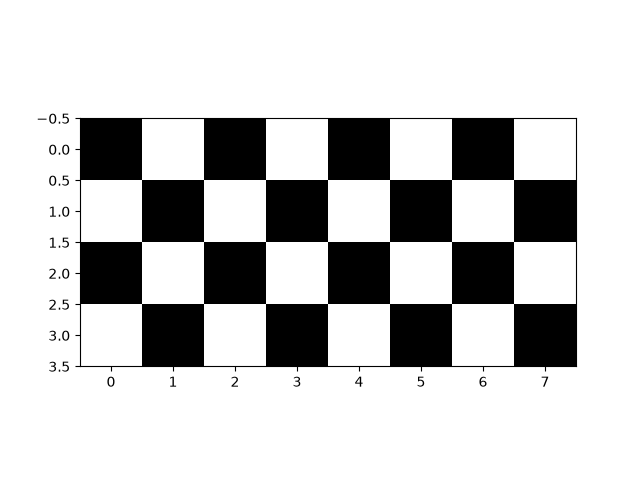

In [5]:
print(image.shape)
plt.figure()
plt.imshow(image.T, cmap = plt.cm.gray);

## sidpy Data Format

The sidpy data format is used to have an representation of data usefull for microscopists. 

A generic dataset in that format is easily created


In [6]:
import sidpy
dataset = sidpy.Dataset.from_array(image, name='checkerboard', quantity='intensity', units='a.u.')    
dataset

sidpy.Dataset of type UNKNOWN with:
 dask.array<array, shape=(8, 4), dtype=float64, chunksize=(8, 4), chunktype=numpy.ndarray>
 data contains: intensity (a.u.)
 and Dimensions: 
a:  generic (generic) of size (8,)
b:  generic (generic) of size (4,)

The sidpy dataset is currently based on dask array, but the development is underway to use a pytorch tensor dataset.
This will not concern any user,e xcept that machine learning tool deployment will be faster.

Let's plot that datset:

In [7]:
print(dataset)

sidpy.Dataset of type UNKNOWN with:
 dask.array<array, shape=(8, 4), dtype=float64, chunksize=(8, 4), chunktype=numpy.ndarray>
 data contains: intensity (a.u.)
 and Dimensions: 
a:  generic (generic) of size (8,)
b:  generic (generic) of size (4,)


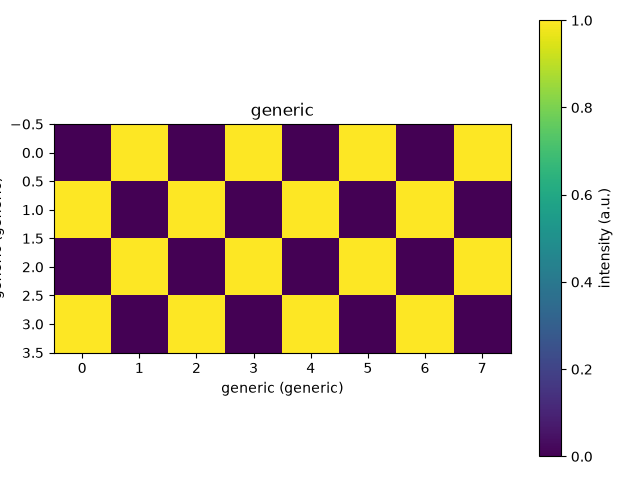

In [8]:
dataset.data_type = 'image'
dataset.a.dimension_type = 'spatial'
dataset.b.dimension_type = 'spatial'

view = dataset.plot()

### Changing the data_type and dimension_type 

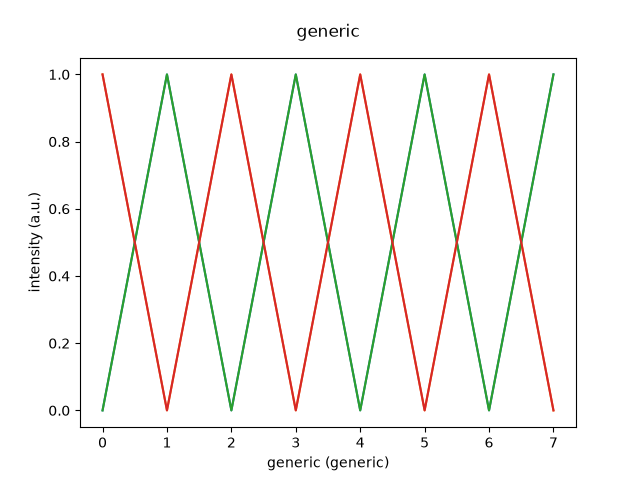

In [9]:
dataset.data_type = 'spectrum'
dataset.a.dimension_type = 'spatial'
dataset.b.dimension_type = 'spectral'

view = dataset.plot()

## Creating an Image-Stack DataSet
In the following we will make a numpy which resembles a stack of images

In the ``sidpy Dataset`` will set the ``data_type`` to ``image_stack`` for the plotting routine to know how to plot this dataset.

The dimensions have to contain at least two ``spatial`` dimensions and one that is identifiable as a stack dimension ('stack, 'frame', 'time').
First we make a stack of images

In [10]:
x = np.random.normal(3, 2.5, size=(25, 512, 512))
x_var = np.random.normal(10, 2.5, size=(25, 512, 512))

dataset = sidpy.Dataset.from_array(x)
dataset.data_type = 'image_stack'
dataset.units = 'counts'
dataset.quantity = 'intensity'

# dataset.variance = x_var

dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0]), 'frame'))
dataset.frame.dimension_type = 'temporal'
dataset.set_dimension(1, sidpy.Dimension(np.arange(dataset.shape[1])*.02, 'x'))
dataset.x.dimension_type = 'spatial'
dataset.x.units = 'nm'
dataset.x.quantity = 'distance'
dataset.set_dimension(2, sidpy.Dimension(np.arange(dataset.shape[2])*.02, 'y'))
dataset.y.dimension_type = 'spatial'
dataset.y.units = 'nm'
dataset.y.quantity = 'distance'


## Plotting the Dataset
Please note that the scroll wheel will move you through the stack, also the slider and the play button will let you navigate through this image stack.

Zoom to an area and let it play!

Click on the ``Average`` button and then click on it again.



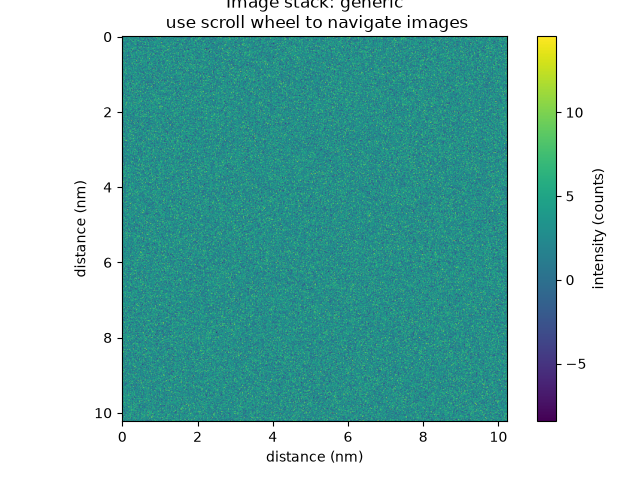

In [11]:
view = dataset.plot(scale_bar=False)

The kwargs dictionary is used to plot the image stack in TEM style with scale bar



Shape of dataset is:  (25, 512, 512)
3D dataset: DataType.IMAGE_STACK


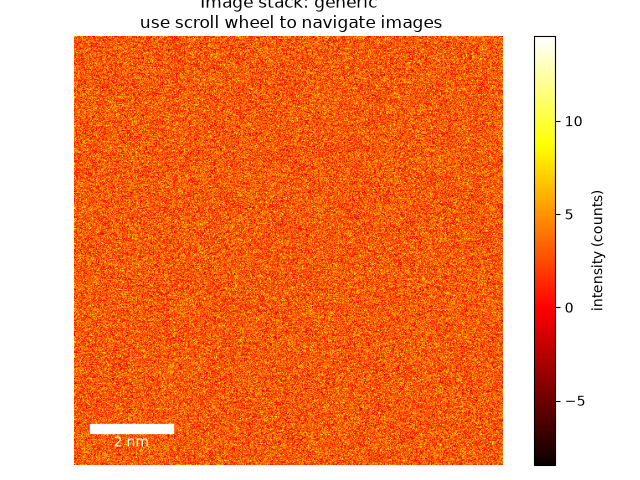

In [12]:
kwargs = {'scale_bar': True, 'cmap': 'hot'}  # or maby 'cmap': 'gray'
 
view = dataset.plot(verbose=True, **kwargs)

## Plot Dataset as Spectral Image
We need to change the data_type of the dataset to ``spectral_image`` and the dimension_type of one dimension to ``spectral``.

Now the plot function plots it as a spectrum image.

Select the spectrum with the mouse (left click).

>
> uncomment the *dataset.variance* line
>



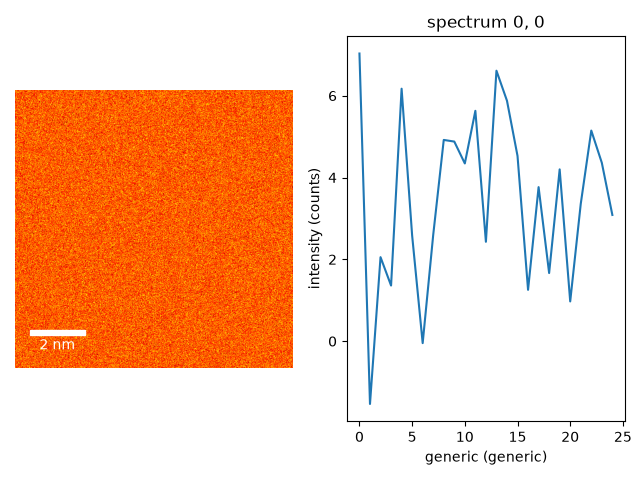

In [13]:
dataset.data_type = 'spectral_image'
dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0]),'spectrum'))
dataset.spectrum.dimension_type = 'spectral'
# dataset.variance = x_var

kwargs = {'scale_bar': True, 'cmap': 'hot'}
view = dataset.plot(**kwargs)


In [14]:
if not os.path.exists('./EELS-Al_LowLoss.dm3'):
    gdown.download('https://drive.google.com/uc?id=10OD8YuX6_N-bkBIPp3EbE57x3NxmQ3D3', './EELS-STO.dm3')
    gdown.download('https://drive.google.com/uc?id=17uJ5Iv6ul06AuXGuPSWRlLhlSGetrh6u', './EELS-Al_LowLoss.dm3')
    gdown.download('https://drive.google.com/uc?id=1vpbIF6dd4544Hx_qCmglMu8HR9v8Kwdt', './EELS-BN_CoreLoss.dm3')
    gdown.download('https://drive.google.com/uc?id=1XRvZE0A0f-V3vIjB9ZphljJh8wQBUGM6', './EELS-BN_LowLoss.dm3')
file_widget = pyTEMlib.file_tools.FileWidget('.')

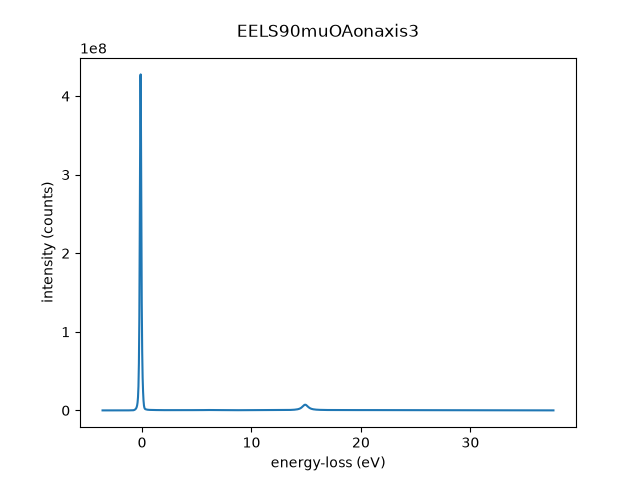

In [55]:
datasets = file_widget.datasets
main_dataset = file_widget.selected_dataset
#plt.close('all')

v = main_dataset.plot()


c:\Users\gduscher\Documents\Github\IMC21-Workshop\notebooks\../../pyTEMlib\pyTEMlib\eels_tools\peak_fit_tools.py:4: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  Copyright by Gerd Duscher
c:\Users\gduscher\Documents\Github\IMC21-Workshop\notebooks\../../pyTEMlib\pyTEMlib\eels_tools\peak_fit_tools.py:4: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  Copyright by Gerd Duscher


10346.305383744599


c:\Users\gduscher\Documents\Github\IMC21-Workshop\notebooks\../../pyTEMlib\pyTEMlib\eels_tools\peak_fit_tools.py:4: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  Copyright by Gerd Duscher


46595.0171924188


c:\Users\gduscher\Documents\Github\IMC21-Workshop\notebooks\../../pyTEMlib\pyTEMlib\eels_tools\peak_fit_tools.py:4: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  Copyright by Gerd Duscher


121619.83444104443
-2003717.184161316


(150, 3)

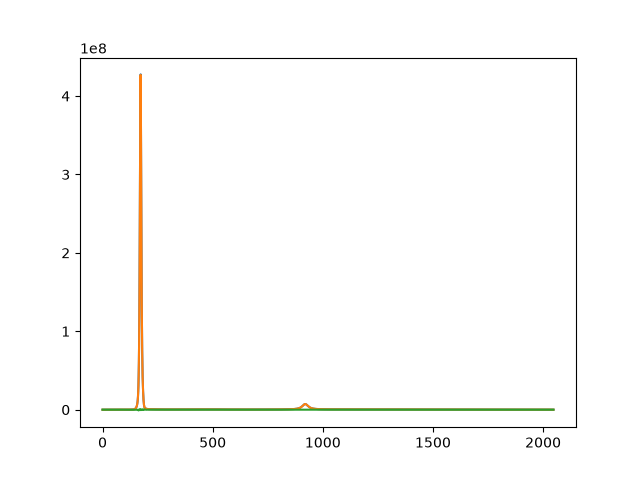

In [62]:

model, p = pyTEMlib.eels_tools.gaussian_mixture_model(main_dataset)#, noise_level=np.std(main_dataset))
p = list(p)
for i in range(4):
    model_1, p_1 = pyTEMlib.eels_tools.gaussian_mixture_model(main_dataset- model) #, noise_level= np.std(main_dataset- model))
    model +=model_1
    print(np.sum(np.array(main_dataset)-model))
    p.extend(list(p_1)) 
plt.close('all')
plt.figure()
plt.plot(main_dataset)
plt.plot(model)

plt.plot(main_dataset-model)
np.array(p).reshape(-1,3)
np.array(p).reshape(-1,3).shape

In [ ]:


from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter
from numba import jit

import scipy
peaks, _ = scipy.signal.find_peaks( gaussian_filter(main_dataset, sigma=2.0), distance=30)

print(len(peaks), "peaks found")

@jit
def gmm(x, p):
    parameters = p.reshape(-1,3)
    
    centers = parameters[:,0]
    amplitudes = parameters[:,1]
    sigmas = parameters[:, 2] * 2.3548
    
    gaussians =  np.exp(-0.5 * ((x[:, None] - centers) / sigmas)**2)  # Shape: (M, NumPeaks)
    
    # Sum across the peaks (columns) to get total model of spectrum: here as a dot product!
    return gaussians @ amplitudes


def residuals3(pp: list[float],
               xx: np.ndarray,
               yy: np.ndarray) -> np.ndarray:
    err = yy - gmm(xx, pp)
    return err
energy_scale =main_dataset.energy_loss.values
spectrum =np.array(main_dataset)
disp = main_dataset.energy_loss.slope
p_in = np.ravel([[energy_scale[peaks[i]], spectrum[peaks[i]],
                3*disp] for i in range(len(peaks))])

[p, _] = scipy.optimize.leastsq(residuals3, p_in, args=(energy_scale, spectrum),maxfev = 10000)
    

113 peaks found


C:\Users\gduscher\AppData\Local\Temp\ipykernel_18664\2446852590.py:35: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  [p, _] = scipy.optimize.leastsq(residuals3, p_in, args=(energy_scale, spectrum),maxfev = 10000)


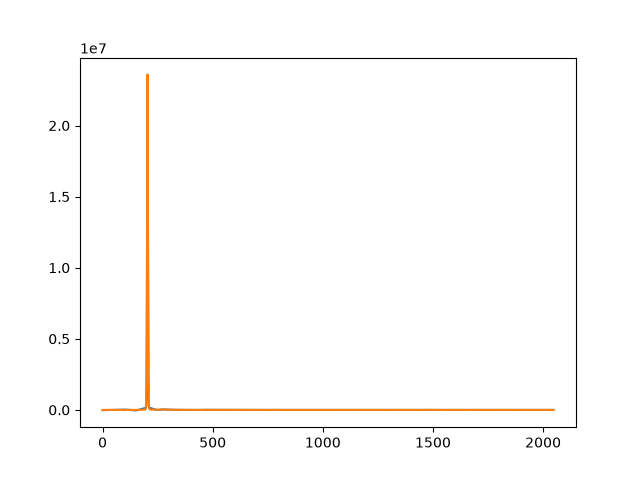

In [58]:
model =  gmm(energy_scale, p)
plt.figure()
plt.plot(model)
plt.plot(spectrum)

465 peaks found
14


C:\Users\gduscher\AppData\Local\Temp\ipykernel_18664\1794721353.py:36: RuntimeWarning: Number of calls to function has reached maxfev = 4.
  [res, _] = scipy.optimize.leastsq(residuals, para, args=(spectrum,),maxfev = 4)


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.0021504 , 0.00205786, 0.00176296, 0.00244768, 0.00259987,
        0.00183482, 0.00242022, 0.0027036 , 0.00180432, 0.00211752,
        0.00176974, 0.00206058, 0.00215277, 0.00195211, 0.00201821,
        0.00172195, 0.00152026, 0.00211142, 0.00191753, 0.00163721,
        0.00194058, 0.00274292, 0.00240259, 0.00174635, 0.00245818,
        0.00187245, 0.0023748 , 0.00214328, 0.00216667, 0.00228395]))

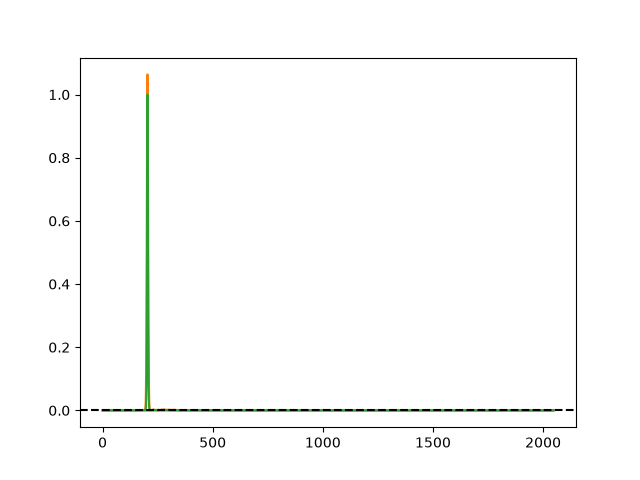

In [ ]:
from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter

import scipy
peaks, _ = scipy.signal.find_peaks(main_dataset, distance=3)

print(len(peaks), "peaks found")

# Automatically creates the kernel and smooths your 1D array
model = np.zeros(main_dataset.shape[0])
model[peaks] = main_dataset[peaks]
spectrum = np.array(main_dataset)-main_dataset.min()
spectrum /= spectrum.max()

def get_model(spectrum, peaks):
    pos = np.asarray(peaks[:int(len(peaks)/2+.5)], dtype=int)
    height = peaks[int(len(peaks)/2+.5):]
    pos[pos<0] = 0
    pos[pos>spectrum.shape[0]] = 0
    height[pos<1] = 0

    model = np.zeros(spectrum.shape[0])
    model[pos] = np.abs(height)
    return gaussian_filter(model, sigma=3.0)

def residuals(spectrum, peaks2):
    return (get_model(spectrum, peaks2) - spectrum) # /np.sqrt(np.abs(spectrum))

def gmm(x, p):
    parameters = p.reshape(-1,3)
    
    centers = parameters[:,0]
    amplitudes = parameters[:,1]
    sigmas = parameters[:, 2] * 2.3548
    
    gaussians =  np.exp(-0.5 * ((x[:, None] - centers) / sigmas)**2)  # Shape: (M, NumPeaks)
    
    # Sum across the peaks (columns) to get total model of spectrum: here as a dot product!
    return gaussians @ amplitudes


def residuals3(pp: list[float],
               xx: np.ndarray,
               yy: np.ndarray) -> np.ndarray:
    err = yy - gmm(xx, pp)
    return err
energy_scale =main_dataset.energy_scale.values
disp = main_dataset.energy_scale.slope
p_in = np.ravel([[energy_scale[peaks[i]], dataset[peaks[i]],
                3*disp] for i in range(len(peaks))])

[p, _] = scipy.optimize.leastsq(residuals3, p_in, args=(energy_scale, spectrum),maxfev = 10000)
    


para = np.zeros((len(peaks)*2))
para[:len(peaks)] = peaks
para[len(peaks):] = np.array(spectrum[peaks])*8

#res_1 = least_squares(residuals, para, args=(spectrum,))

[res, _] = scipy.optimize.leastsq(residuals3, para, args=(spectrum,),maxfev = 4)

model1 = get_model(spectrum, para)
model = get_model(spectrum, res)
print(sum(res[:int(len(res)/2)]>0))
plt.close('all')
plt.figure()
plt.plot(model)

plt.plot(model1)
plt.plot(spectrum)
#plt.plot(smoothed_1d- main_dataset)

plt.axhline(0, color='k', ls='--')
np.asarray(res[-30:]), para[-30:]


In [ ]:

# Automatically creates the kernel and smooths your 1D array
model = np.zeros(main_dataset.shape[0])
model[peaks] = main_dataset[peaks]
spectrum = np.array(main_dataset)
def residuals(peaks):
    
    model = np.zeros(spectrum.shape[0])
    model[np.asarray(peaks[:int(len(peaks)/2)], dtype=int)] = peaks[int(len(peaks)/2):]
    
    return gaussian_filter(model, sigma=2.0)*5 - spectrum


from scipy.optimize import least_squares

para = np.zeros((len(peaks)*2))
para[:len(peaks)] = peaks
para[len(peaks):] = main_dataset[peaks]
res_1 = least_squares(residuals, para)
model = np.zeros(spectrum.shape[0])
model[np.asarray(res_1.x[:int(len(res_1.x)/2)], dtype=int)] = res_1.x[int(len(res_1.x)/2):]
smoothed_1d = gaussian_filter(model, sigma=2.0)*5 

plt.figure()
plt.plot(smoothed_1d)
plt.plot(main_dataset)


IndexError: index 188749 is out of bounds for axis 0 with size 2048

## Summary

So internally we use the mathematical convention of matrices and all we have to take care of is that the output plot of the image is the right kind around. 

For absolute pixel positions we need to shift the ``grid`` by half a pixel to keep the pixel origin in the center of the pixels.

The advantage of this approach is that no other effort has to be spent to keep track on what axis is where, which can get cumbersome in multidimensional datasets.

## Navigation
- <font size = "3">  **Back  [Installation and Prerequisites](CH1_02-Prerequisites.ipynb))** </font>
- <font size = "3">  **Next: [Open a (DM) file ](CH1_04-Open_File.ipynb)** </font>
- <font size = "3">  **Chapter 1: [Introduction](CH1_00-Introduction.ipynb)** </font>
- <font size = "3">  **List of Content: [Front](../_MSE672_Intro_TEM.ipynb)** </font>
